Iter 0: log-likelihood = -501.6404
Saving snapshot at iteration 0
Iter 1: log-likelihood = -444.7550
Saving snapshot at iteration 1
Iter 2: log-likelihood = -410.9916
Saving snapshot at iteration 2
Iter 3: log-likelihood = -396.4115
Iter 4: log-likelihood = -387.2182
Iter 5: log-likelihood = -385.5226
Saving snapshot at iteration 5
Iter 6: log-likelihood = -385.4635
Iter 7: log-likelihood = -385.4608
Iter 8: log-likelihood = -385.4607
Iter 9: log-likelihood = -385.4607
Iter 10: log-likelihood = -385.4607
Iter 11: log-likelihood = -385.4607
Iter 12: log-likelihood = -385.4607
Iter 13: log-likelihood = -385.4607
Iter 14: log-likelihood = -385.4607
Iter 15: log-likelihood = -385.4607
Iter 16: log-likelihood = -385.4607
Iter 17: log-likelihood = -385.4607
Iter 18: log-likelihood = -385.4607
Iter 19: log-likelihood = -385.4607
Iter 20: log-likelihood = -385.4607
Saving snapshot at iteration 20
Iter 21: log-likelihood = -385.4607
Iter 22: log-likelihood = -385.4607
Iter 23: log-likelihood = 

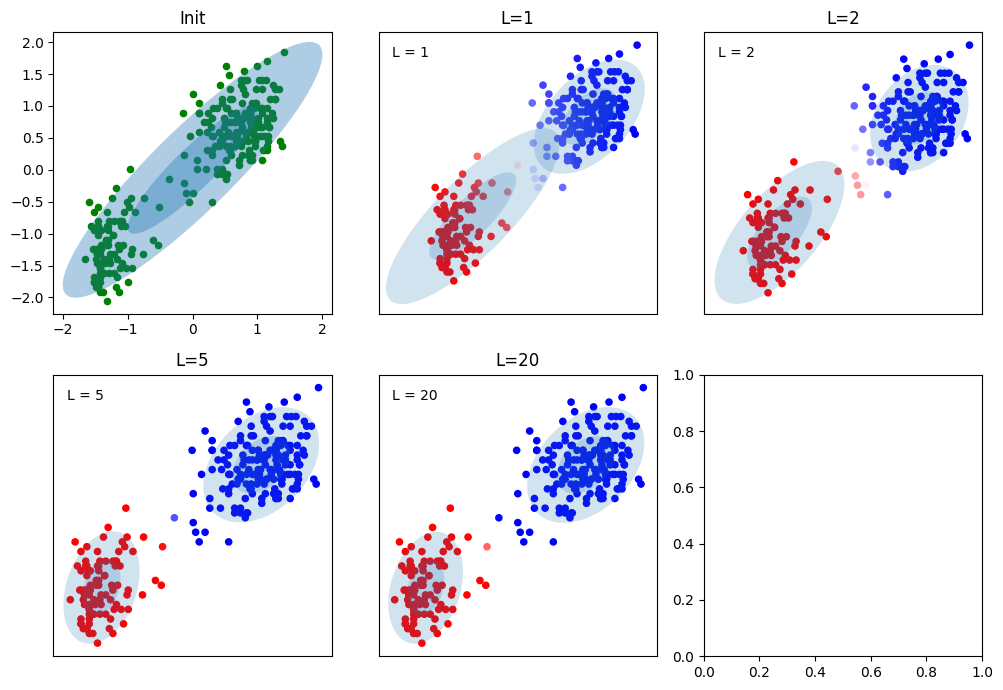

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans
from matplotlib.patches import Ellipse

# ========== Helper functions ==========
def gaussian_pdf(X, mean, cov):
    return multivariate_normal(mean=mean, cov=cov, allow_singular=True).pdf(X)

def e_step(X, means, covs, pis):
    n, K = X.shape[0], len(pis)
    resp = np.zeros((n, K))
    for k in range(K):
        resp[:, k] = pis[k] * gaussian_pdf(X, means[k], covs[k])
    resp /= resp.sum(axis=1, keepdims=True)
    return resp

def m_step(X, resp):
    n, d = X.shape
    K = resp.shape[1]
    Nk = resp.sum(axis=0)
    means, covs, pis = np.zeros((K, d)), np.zeros((K, d, d)), Nk / n
    for k in range(K):
        r = resp[:, k][:, np.newaxis]
        means[k] = (r * X).sum(axis=0) / Nk[k]
        Xc = X - means[k]
        covs[k] = (r * Xc).T @ Xc / Nk[k] + 1e-6 * np.eye(d)
    return means, covs, pis

def log_likelihood(X, means, covs, pis):
    total = np.zeros(X.shape[0])
    for k in range(len(pis)):
        total += pis[k] * gaussian_pdf(X, means[k], covs[k])
    return np.sum(np.log(total + 1e-16))

def draw_ellipse(ax, mean, cov, color):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    for s in [1, 2]:
        width, height = 2 * s * np.sqrt(vals)
        e = Ellipse(xy=mean, width=width, height=height, angle=angle, alpha=0.2)
        ax.add_patch(e)

# ========== EM algorithm with snapshots ==========
def em_gmm_with_snapshots(X, K=2, max_iters=21, tol=1e-6, init='kmeans', verbose=False):
    n, d = X.shape
    # init
    if init == 'kmeans':
        km = KMeans(n_clusters=K, random_state=0).fit(X)
        means = km.cluster_centers_
        covs = np.array([np.cov(X.T) + 1e-6*np.eye(d) for _ in range(K)])
        pis = np.ones(K) / K
    else:
        means = X[np.random.choice(n, K, replace=False)]
        covs = np.array([np.cov(X.T) + 1e-6*np.eye(d) for _ in range(K)])
        pis = np.ones(K) / K

    snapshots = {0: (means.copy(), covs.copy(), pis.copy(), np.ones((n, K))/K)}
    ll_trace = []
    snapshot_iters = [0,1, 2, 5, 20]

    for it in range(0, max_iters):
        resp = e_step(X, means, covs, pis)
        means, covs, pis = m_step(X, resp)
        ll = log_likelihood(X, means, covs, pis)
        ll_trace.append(ll)
        if verbose:
            print(f"Iter {it}: log-likelihood = {ll:.4f}")
        if it in snapshot_iters:
            print(f"Saving snapshot at iteration {it}")
            snapshots[it] = (means.copy(), covs.copy(), pis.copy(), resp.copy())

    return {'means': means, 'covs': covs, 'pis': pis,
            'resp': resp, 'll_trace': ll_trace, 'snapshots': snapshots}

# ========== Visualization ==========
def plot_em_progress(X, snapshots):
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    axes = axes.flatten()
    titles = ['Init', 'L=1', 'L=2', 'L=5', 'L=20']
    Ks = ['blue', 'red']

    # (a) initial plot
    ax = axes[0]
    ax.scatter(X[:,0], X[:,1], s=20, c='green')
    ax.set_title(titles[0])
    for c, mean, cov in zip(Ks, [X.mean(axis=0)]*2, [np.cov(X.T)]*2):
        draw_ellipse(ax, mean, cov, c)

    # subsequent snapshots
    for i, L in enumerate([1, 2, 5, 20], start=1):
        if L not in snapshots: continue
        ax = axes[i]
        means, covs, pis, resp = snapshots[L]
        colors = resp[:, 0]
        ax.scatter(X[:,0], X[:,1], c=colors, cmap='bwr', s=20)
        for k, c in zip(range(len(means)), Ks):
            draw_ellipse(ax, means[k], covs[k], c)
        ax.text(0.05, 0.95, f'L = {L}', transform=ax.transAxes, fontsize=10,
                verticalalignment='top')
        ax.set_title(titles[i])
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()

# ========== Run on Old Faithful ==========
if __name__ == "__main__":
    # Load dataset
    DATA_PATH = "faithful.csv"  # update if needed
    df = pd.read_csv(DATA_PATH)
    X = df[['eruptions', 'waiting']].values
    # Optional: standardize for better ellipse scaling
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    results = em_gmm_with_snapshots(X, K=2, max_iters=50, tol=1e-5, verbose=True)
    print(len(results['snapshots']))
    plot_em_progress(X, results['snapshots'])
